In [3]:
import pandas as pd

df = pd.read_csv("GojekAppReviewV4.0.0-V4.9.3_Cleaned.csv")
df.head()

,userName,content,score,at,appVersion
0,Yuga Edit,akun gopay saya di blok,1,2022-01-21 10:52:12,4.9.3
1,ff burik,Lambat sekali sekarang ini bosssku apk gojek g...,3,2021-11-30 15:40:38,4.9.3
2,Anisa Suci Rahmayuliani,Kenapa sih dari kemarin sy buka aplikasi gojek...,4,2021-11-29 22:58:12,4.9.3
3,naoki yakuza,Baru download gojek dan hape baru trus ditop u...,1,2022-09-03 15:21:17,4.9.3
4,Trio Sugianto,Mantap,5,2022-01-15 10:05:27,4.9.3


In [4]:
df.shape

(225002, 5)

In [5]:
df.isnull().sum()

,0
userName,0
content,2
score,0
at,0
appVersion,0


In [6]:
df = df.dropna(subset=["content"])

In [7]:
def map_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["score"].apply(map_sentiment)

In [8]:
df["sentiment"].value_counts()

,count
sentiment,
positive,161369
negative,54171
neutral,9460


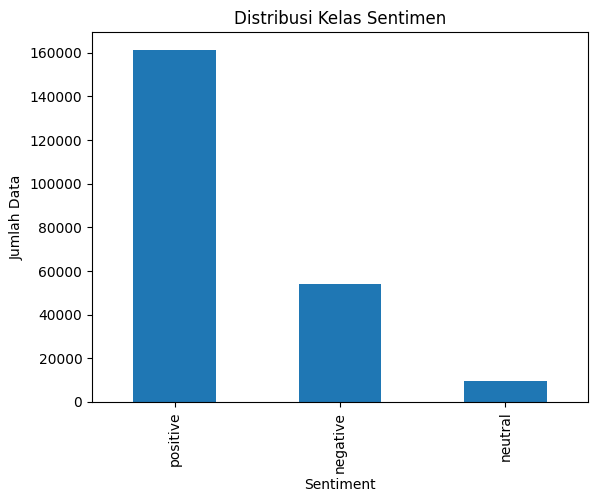

In [9]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Distribusi Kelas Sentimen")
plt.xlabel("Sentiment")
plt.ylabel("Jumlah Data")
plt.show()

In [10]:
df = df[["content", "sentiment"]]
df.head()

,content,sentiment
0,akun gopay saya di blok,negative
1,Lambat sekali sekarang ini bosssku apk gojek g...,neutral
2,Kenapa sih dari kemarin sy buka aplikasi gojek...,positive
3,Baru download gojek dan hape baru trus ditop u...,negative
4,Mantap,positive


In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["sentiment"])

label_encoder.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [12]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

len(train_df), len(val_df), len(test_df)

(157500, 33750, 33750)

In [13]:
from transformers import AutoTokenizer

tokenizer_indobert = AutoTokenizer.from_pretrained(
    "indobenchmark/indobert-base-p1"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [14]:
def tokenize_function(examples, tokenizer):
    return tokenizer(
        examples["content"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [15]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

In [16]:
train_indobert = train_dataset.map(
    lambda x: tokenize_function(x, tokenizer_indobert),
    batched=True
)

val_indobert = val_dataset.map(
    lambda x: tokenize_function(x, tokenizer_indobert),
    batched=True
)

test_indobert = test_dataset.map(
    lambda x: tokenize_function(x, tokenizer_indobert),
    batched=True
)

Map:   0%|          | 0/157500 [00:00<?, ? examples/s]

Map:   0%|          | 0/33750 [00:00<?, ? examples/s]

Map:   0%|          | 0/33750 [00:00<?, ? examples/s]

In [17]:
columns = ["input_ids", "attention_mask", "label"]

train_indobert.set_format(type="torch", columns=columns)
val_indobert.set_format(type="torch", columns=columns)
test_indobert.set_format(type="torch", columns=columns)

In [18]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=3
)

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [20]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results_indobert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
)


In [21]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_indobert,
    eval_dataset=val_indobert,
    compute_metrics=compute_metrics
)

In [22]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.295400,0.306412,0.898667,0.887917,0.898667,0.882500
2,0.262900,0.306929,0.906044,0.904369,0.906044,0.890390
3,0.230100,0.334988,0.899822,0.884528,0.899822,0.889962


TrainOutput(global_step=29532, training_loss=0.2760304185121214, metrics={'train_runtime': 2652.5821, 'train_samples_per_second': 178.128, 'train_steps_per_second': 11.133, 'total_flos': 3.108027246912e+16, 'train_loss': 0.2760304185121214, 'epoch': 3.0})

In [23]:
test_results = trainer.evaluate(test_indobert)
test_results

{'eval_loss': 0.3407554626464844,
 'eval_accuracy': 0.8979555555555555,
 'eval_precision': 0.8829844795105494,
 'eval_recall': 0.8979555555555555,
 'eval_f1': 0.8884946997969292,
 'eval_runtime': 59.3866,
 'eval_samples_per_second': 568.31,
 'eval_steps_per_second': 35.53,
 'epoch': 3.0}

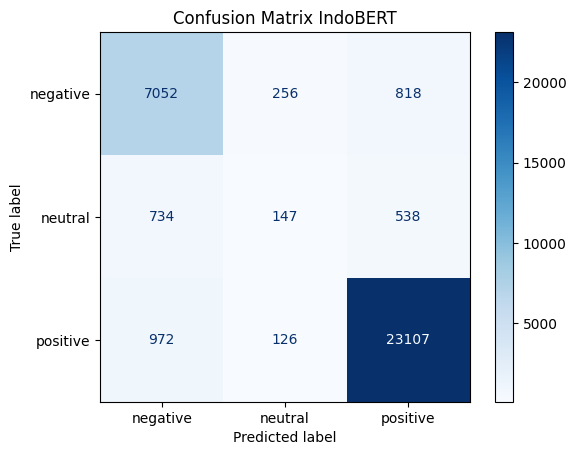

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = trainer.predict(test_indobert)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix IndoBERT")
plt.show()

In [25]:
def load_indobert_model():
    return AutoModelForSequenceClassification.from_pretrained(
        "indobenchmark/indobert-base-p1",
        num_labels=3
    )

In [26]:
from transformers import TrainingArguments, Trainer

training_args_lr_small = TrainingArguments(
    output_dir="./results_lr_small",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,  # lebih kecil
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs_lr_small",
    load_best_model_at_end=True
)

trainer_lr_small = Trainer(
    model=load_indobert_model(),
    args=training_args_lr_small,
    train_dataset=train_indobert,
    eval_dataset=val_indobert,
    compute_metrics=compute_metrics
)

trainer_lr_small.train()

eval_lr_small = trainer_lr_small.evaluate(test_indobert)
eval_lr_small

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.287100,0.295981,0.904444,0.889759,0.904444,0.890823
2,0.257100,0.307442,0.905333,0.892832,0.905333,0.890380
3,0.232900,0.327321,0.901096,0.885580,0.901096,0.891005


{'eval_loss': 0.29446548223495483,
 'eval_accuracy': 0.9039703703703704,
 'eval_precision': 0.8894574898993751,
 'eval_recall': 0.9039703703703704,
 'eval_f1': 0.8899491711011831,
 'eval_runtime': 59.7885,
 'eval_samples_per_second': 564.49,
 'eval_steps_per_second': 35.291,
 'epoch': 3.0}

In [27]:
training_args_bs_small = TrainingArguments(
    output_dir="./results_bs_small",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,   # batch size kecil
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs_bs_small",
    load_best_model_at_end=True
)

trainer_bs_small = Trainer(
    model=load_indobert_model(),
    args=training_args_bs_small,
    train_dataset=train_indobert,
    eval_dataset=val_indobert,
    compute_metrics=compute_metrics
)

trainer_bs_small.train()

eval_bs_small = trainer_bs_small.evaluate(test_indobert)
eval_bs_small

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.359900,0.320860,0.902874,0.901524,0.902874,0.886774
2,0.301400,0.361697,0.904415,0.901443,0.904415,0.888868
3,0.266600,0.368827,0.901452,0.883778,0.901452,0.889626


{'eval_loss': 0.3185221552848816,
 'eval_accuracy': 0.9021925925925925,
 'eval_precision': 0.8965905203900874,
 'eval_recall': 0.9021925925925925,
 'eval_f1': 0.8855812405615764,
 'eval_runtime': 68.1699,
 'eval_samples_per_second': 495.087,
 'eval_steps_per_second': 61.89,
 'epoch': 3.0}

In [28]:
import pandas as pd

comparison_df = pd.DataFrame([
    {
        "Eksperimen": "Baseline (LR=2e-5, BS=16)",
        "Accuracy": test_results["eval_accuracy"],
        "Precision": test_results["eval_precision"],
        "Recall": test_results["eval_recall"],
        "F1": test_results["eval_f1"]
    },
    {
        "Eksperimen": "LR kecil (1e-5, BS=16)",
        "Accuracy": eval_lr_small["eval_accuracy"],
        "Precision": eval_lr_small["eval_precision"],
        "Recall": eval_lr_small["eval_recall"],
        "F1": eval_lr_small["eval_f1"]
    },
    {
        "Eksperimen": "BS kecil (LR=2e-5, BS=8)",
        "Accuracy": eval_bs_small["eval_accuracy"],
        "Precision": eval_bs_small["eval_precision"],
        "Recall": eval_bs_small["eval_recall"],
        "F1": eval_bs_small["eval_f1"]
    }
])

comparison_df

,Eksperimen,Accuracy,Precision,Recall,F1
0,"Baseline (LR=2e-5, BS=16)",0.897956,0.882984,0.897956,0.888495
1,"LR kecil (1e-5, BS=16)",0.903970,0.889457,0.903970,0.889949
2,"BS kecil (LR=2e-5, BS=8)",0.902193,0.896591,0.902193,0.885581
